In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np

In [17]:
# Filename example AIRS.2007.04.28.044.L1B.AMSU_Rad.v5.0.0.0.G07233155454.hdf
# o ggg = granule number [1-240]
# productionTimeStamp = file creation time stamp. yy: year number without century; ddd: day of a year [1-366]; hhmmss: time. (1216 here)

#ds = xr.open_dataset('/Users/bmapes/Downloads/AIRS.2025.03.14.153.L1B.AMSU_Rad.v5.0.14.0.R25073121626.hdf.nc4')
ds = xr.open_dataset('/Users/bmapes/Downloads/AIRS.2025.03.14.199.L1B.AMSU_Rad.v5.0.14.0.R25073170119.hdf.nc4')
ds = xr.open_dataset('/Users/bmapes/Downloads/AIRS.2025.03.14.201.L1B.AMSU_Rad.v5.0.14.0.R25073184013.hdf.nc4')
ds

<xarray.Dataset> Size: 427kB
Dimensions:                               (GeoTrack: 45, GeoXTrack: 30,
                                           Channel: 15, BBXTrack: 2,
                                           SpaceXTrack: 2, CalXTrack: 4,
                                           WarmPRTA11: 5, WarmPRTA12: 5,
                                           WarmPRTA2: 7)
Coordinates:
    center_freq                           (Channel) float32 60B ...
    Latitude                              (GeoTrack, GeoXTrack) float64 11kB ...
    Longitude                             (GeoTrack, GeoXTrack) float64 11kB ...
  * CalXTrack                             (CalXTrack) int32 16B 0 1 2 3
  * SpaceXTrack                           (SpaceXTrack) int32 8B 0 1
  * BBXTrack                              (BBXTrack) int32 8B 0 1
  * WarmPRTA11                            (WarmPRTA11) int32 20B 0 1 2 3 4
  * WarmPRTA12                            (WarmPRTA12) int32 20B 0 1 2 3 4
  * WarmPRTA2                             (WarmPRTA2) int32 28B 0 1 2 3 4 5 6
Dimensions without coordinates: GeoTrack, GeoXTrack, Channel
Data variables: (12/171)
    scanang                               (GeoTrack, GeoXTrack) float32 5kB ...
    satheight                             (GeoTrack) float32 180B ...
    satroll                               (GeoTrack) float32 180B ...
    satpitch                              (GeoTrack) float32 180B ...
    satyaw                                (GeoTrack) float32 180B ...
    satgeoqa                              (GeoTrack) int32 180B ...
    ...                                    ...
    qa_scanline                           (GeoTrack) int16 90B ...
    qa_receiver_a11                       (GeoTrack) int16 90B ...
    qa_receiver_a12                       (GeoTrack) int16 90B ...
    qa_receiver_a2                        (GeoTrack) int16 90B ...
    qa_channel                            (GeoTrack, Channel) float32 3kB ...
    Time                                  (GeoTrack, GeoXTrack) float64 11kB ...
Attributes: (12/153)
    HDFEOSVersion:                            HDFEOS_V2.12
    L1B_AMSU.SWATH_TITLE__:                   L1B_AMSU
    L1B_AMSU.processing_level:                Level1B
    L1B_AMSU.instrument:                      AMSU
    L1B_AMSU.DayNightFlag:                    Day
    L1B_AMSU.AutomaticQAFlag:                 Suspect
    ...                                       ...
    L1B_AMSU.QA_rec_PRT_a2_max_track:         0
    L1B_AMSU.QA_rec_PRT_a2_max_xtrack:        0
    L1B_AMSU.QA_rec_PRT_a2_min_track:         0
    L1B_AMSU.QA_rec_PRT_a2_min_xtrack:        0
    L1B_AMSU.granules_present:                Next
    history:                                  2025-03-17 18:20:22 GMT Hyrax-1...

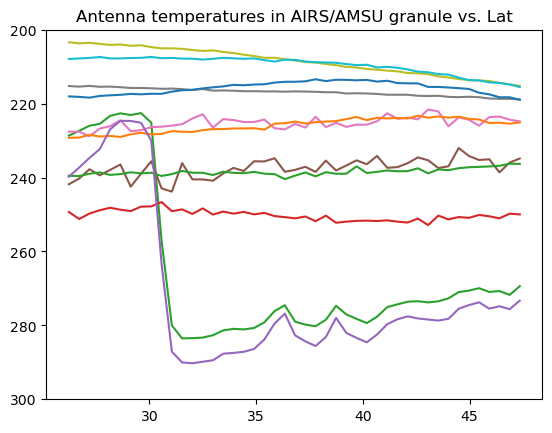

In [66]:
ds = xr.open_dataset('/Users/bmapes/Downloads/AIRS.2025.03.14.201.L1B.AMSU_Rad.v5.0.14.0.R25073184013.hdf.nc4')

plt.plot(ds.Latitude[:,15], ds.antenna_temp[:,15,:]);  plt.ylim([300,200]);
plt.title('Antenna temperatures in AIRS/AMSU granule vs. Lat');

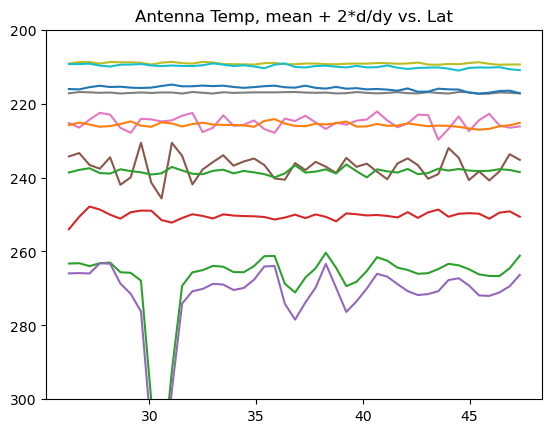

In [67]:
Tbmean = ds.antenna_temp[:,15,:].mean('GeoTrack')
Tbdiff = ds.antenna_temp[:,15,:].differentiate('GeoTrack')

plt.plot(ds.Latitude[:,15], (Tbmean + 2*Tbdiff).transpose()); plt.ylim([300,200]);
plt.title('Antenna Temp, mean + 2*d/dy vs. Lat');

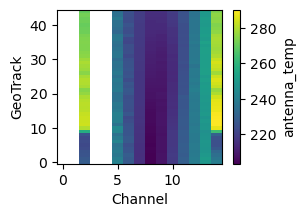

In [36]:
ds.antenna_temp[:,15,:].plot(size=2)

# Grr, why is the data not on the supposed Aqual orbit? 
#ds = xr.open_dataset('/Users/bmapes/Downloads/AIRS.2025.03.14.153.L1B.AMSU_Rad.v5.0.14.0.R25073121626.hdf.nc4')

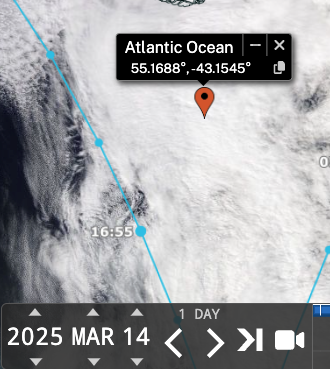

In [70]:
ds.Time[0][0].values

array(1.01613633e+09)